# Planet Habitable Zone Prediction

The habitable zone is the range of orbital distances from a star where liquid water could exist on a planet's surface. Whether a planet lies in this zone depends on things like equilibrium temperature, orbital period, and the properties of the host star.

This is a binary classification problem. We are predicting whether an exoplanet is in the habitable zone (1.0) or not (0.0). The data is heavily imbalanced since only about 7% of planets are habitable.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_cleaned = pd.read_csv('./data/X_Habitable.csv')
y_cleaned = pd.read_csv('./data/Y_Habitable.csv')

X_cleaned = X_cleaned.drop(columns=['Unnamed: 0'])
y_cleaned = y_cleaned.drop(columns=['Unnamed: 0'])

X_cleaned

,equilibrium_temp_k,orbital_period_days,orbital_period_cat,star_radius_sun,star_temp_k,star_surface_gravity,planet_radius_earth,discovery_method,planet_mass_earth,star_mass_sun,star_vmag,dec,dist_from_earth_pc,orbital_eccentricity,disc_facility
0,1.135022,-0.171515,0.086983,-0.325910,-0.346503,0.545130,-0.737404,0.362164,-0.339552,-0.446628,1.166737,0.776258,0.185982,-0.498783,-0.452829
1,-0.103871,-0.167536,0.086983,-0.208112,0.307777,0.252465,-0.421339,0.362164,-0.329885,0.055170,0.961122,0.535072,0.431534,-0.498783,-0.452829
2,0.448220,-0.168584,0.086983,0.038884,0.590348,-0.295195,-0.915694,0.362164,-0.343628,0.635681,-0.083252,0.553801,-0.148125,-0.498783,-0.452829
3,1.656197,-0.170310,0.086983,0.479677,1.236606,-0.932684,-0.455276,0.362164,-0.331056,1.849180,0.467714,0.660749,0.692800,-0.498783,-0.452829
4,-1.073344,-0.140789,-0.727363,-0.271951,0.076907,0.327805,-0.182824,0.362164,-0.319866,-0.335117,1.159074,0.873288,0.330728,-0.498783,-0.452829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5837,-0.560120,1.692285,1.715674,0.057397,-0.265030,-0.141039,1.631302,-4.459542,0.094137,-0.840195,3.790501,-1.274353,4.935734,-0.290753,-0.588308
5838,-1.062303,-0.170801,0.086983,-0.738203,-2.076691,1.675224,-0.876510,0.362164,-0.342932,-2.476778,0.997876,1.799321,-0.627908,-0.293084,1.850311
5839,-0.651546,-0.125507,-0.727363,0.578475,0.487838,-1.599149,0.242210,0.362164,-0.296837,1.291626,-0.805853,-2.209859,-0.382631,-0.498783,1.850311
5840,-0.240790,-0.170875,0.086983,-0.486267,-1.511550,0.979782,-0.801667,0.362164,-0.339929,-1.273119,-0.156760,0.793690,-0.614510,-0.395933,1.850311


## Exploratory Data Analysis

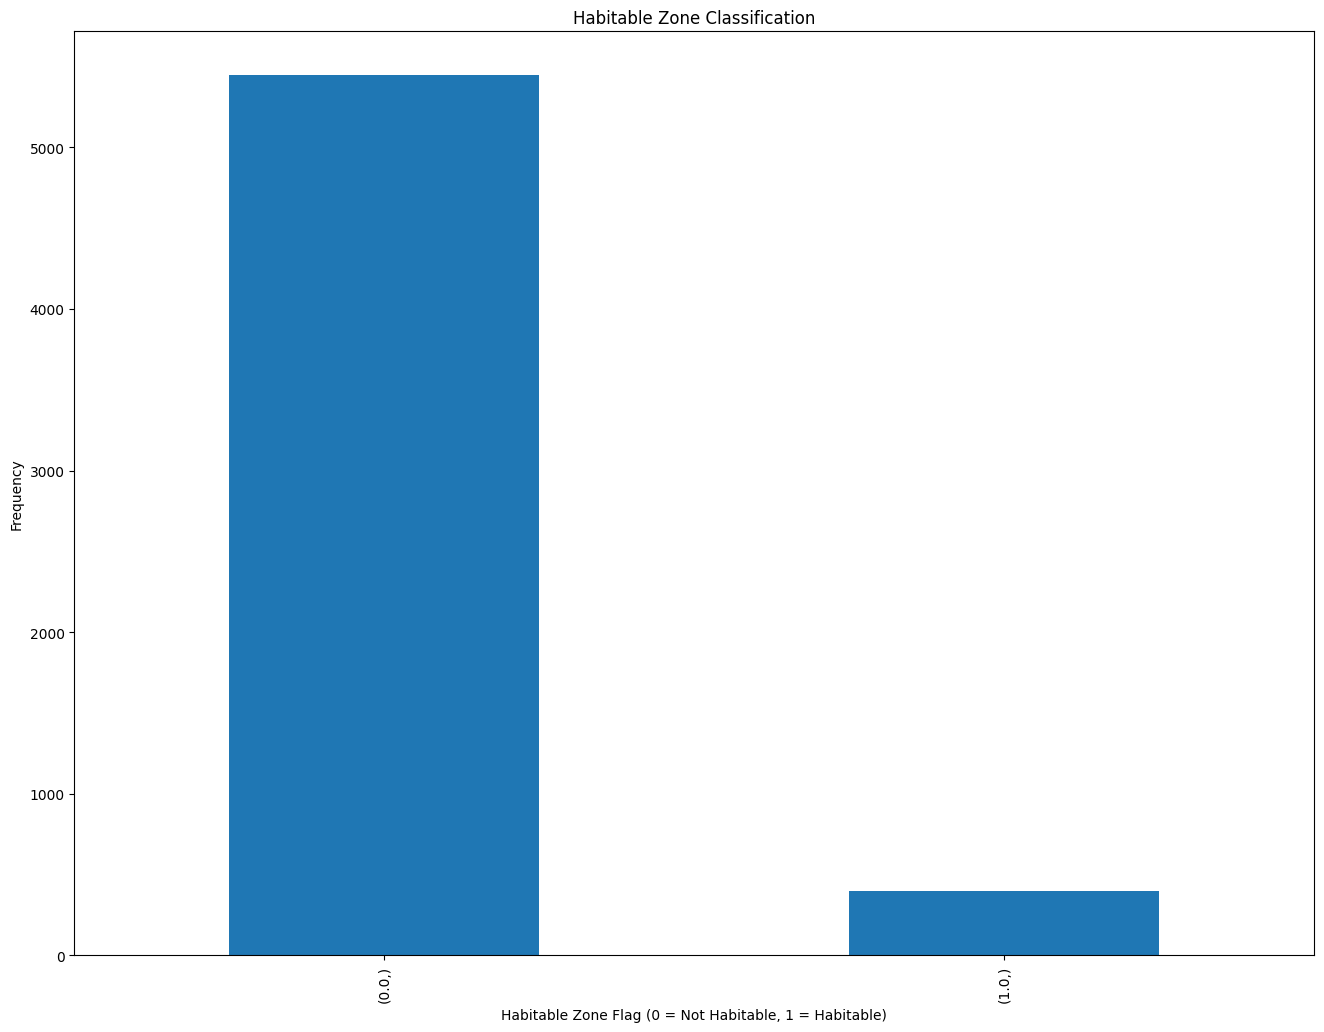

In [3]:
plt.figure(figsize=(16, 12))
y_cleaned.value_counts().sort_index().plot(kind='bar', title='Habitable Zone Classification')
plt.xlabel('Habitable Zone Flag (0 = Not Habitable, 1 = Habitable)')
plt.ylabel('Frequency')
plt.show()

There is a large class imbalance here. Only about 7% of planets are in the habitable zone. We can use PCA and KMeans to check if there is any natural clustering in the data:

## Unsupervised Clustering

In [4]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

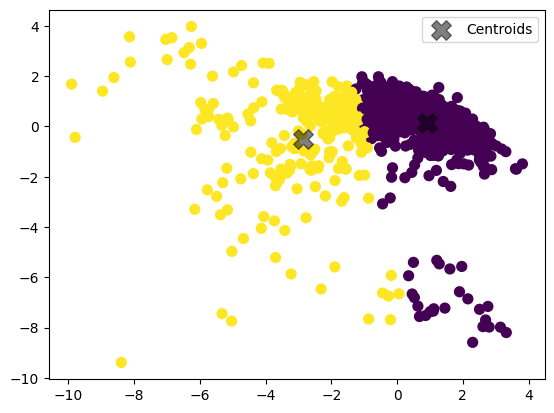

In [5]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_cleaned)

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_cleaned, test_size=0.2, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans.fit(X_train)
y_kmeans = kmeans.predict(X_test)

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X', label='Centroids')
plt.legend()
plt.show()

Comparing the KMeans clusters against the actual habitable zone labels:

In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [7]:
cm = confusion_matrix(y_test, y_kmeans)

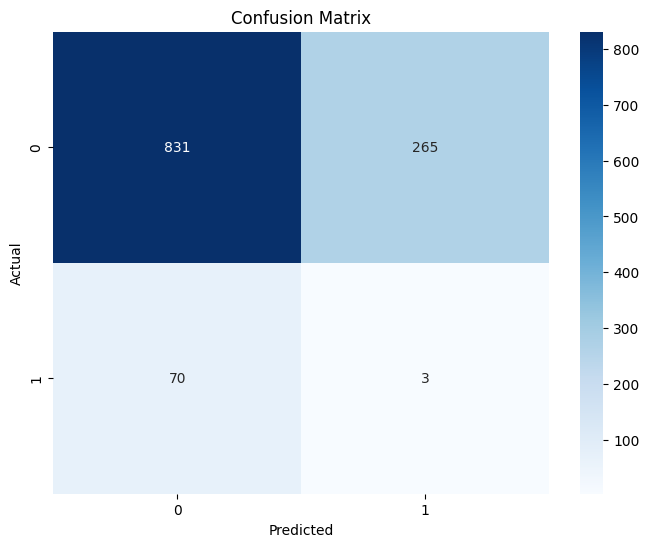

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
silhouette_score(X_test, y_kmeans)

0.5163843333947525

Trying KMeans again without PCA to see if using all features helps:

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

kmeans2 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans2.fit(X_train)
y_kmeans2 = kmeans2.predict(X_test)

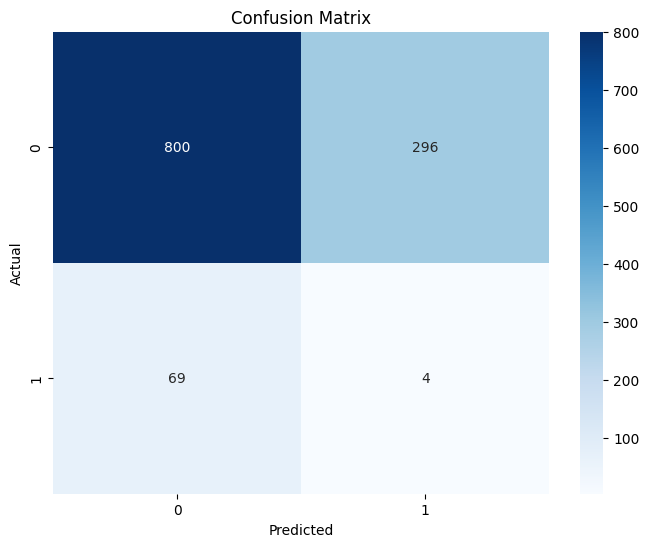

In [11]:
cm = confusion_matrix(y_test, y_kmeans2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Classification

### K-Nearest Neighbors

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

In [14]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train.values.ravel())
y_pred = neigh.predict(X_test)

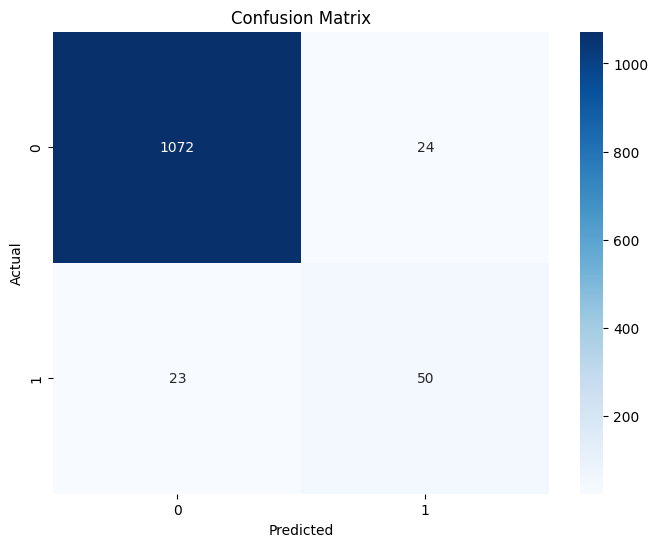

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9597946963216424


### K-Nearest Neighbors with SMOTE

Using SMOTE to oversample the minority class in the training data to address the class imbalance.

In [17]:
from imblearn.over_sampling import SMOTE

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_res, y_res.values.ravel())
y_pred = neigh.predict(X_test)

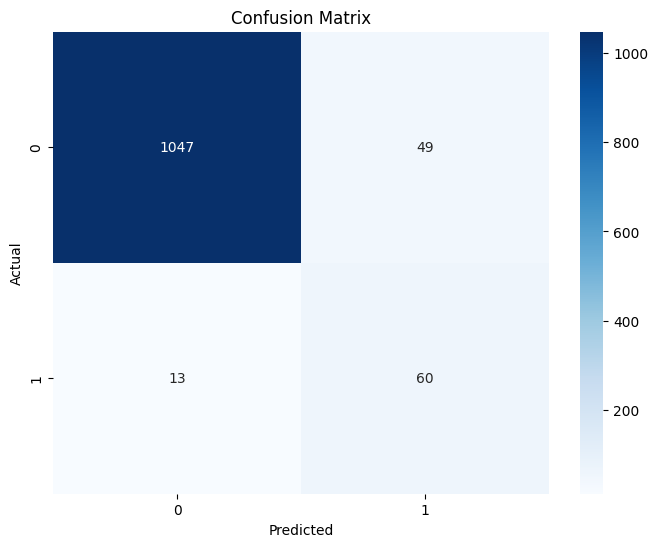

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

In [22]:
clf = RandomForestClassifier(max_depth=10, random_state=0)
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)

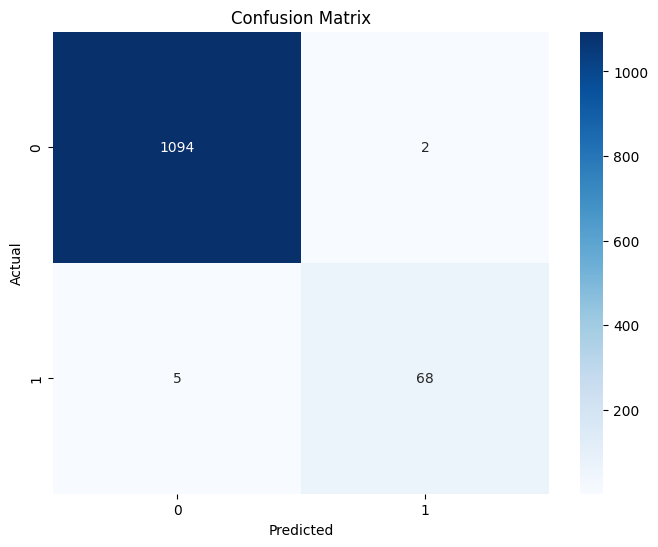

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()